  1. CIRCULAR ORBITS PARAMETERS
LEO Altitude: 300.00 km | Velocity: 7.7258 km/s
GEO Altitude: 35786.00 km | Velocity: 3.0747 km/s

  2. HOHMANN TRANSFER RESULTS (LEO -> GEO)
Perigee Velocity (Tx): 10.1515 km/s
Apogee Velocity (Tx):  1.6078 km/s
Time of Flight (TOF):  5.28 hours

  3. TOTAL DELTA-V BUDGET
Delta V 1 (Perigee Burn):       2.4257 km/s
Delta V 2 (Circulariz.): 1.4668 km/s
TOTAL DELTA V:           3.8926 km/s


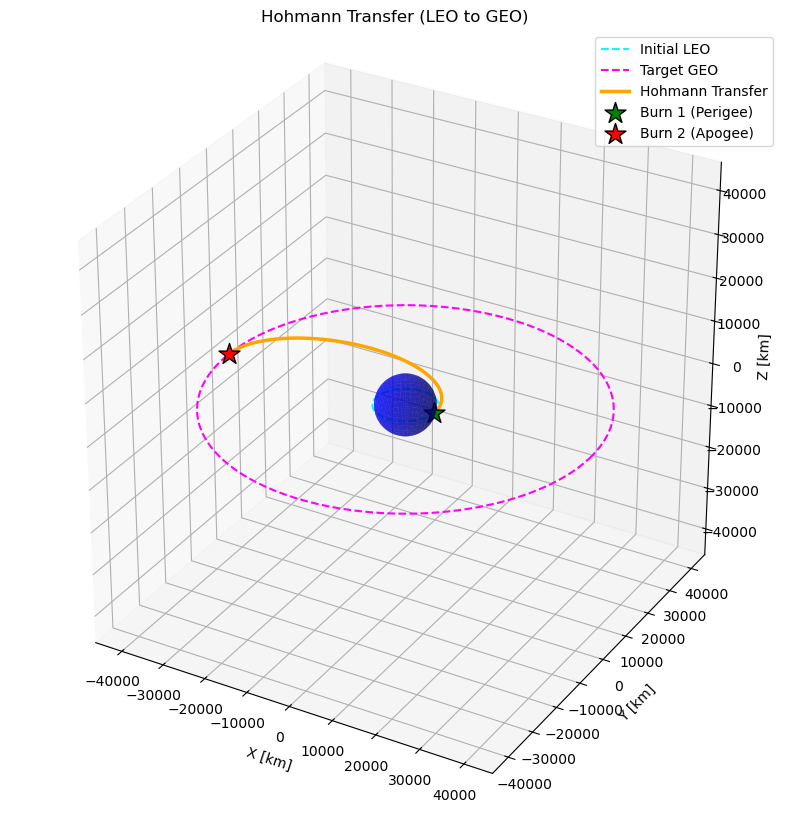

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import orekit
from orekit.pyhelpers import setup_orekit_curdir
from org.orekit.utils import Constants

# ==========================================
# 1. OREKIT ENVIRONMENT INITIALIZATION
# ==========================================
orekit.initVM()
setup_orekit_curdir('C:/Users/Simone/Downloads/orekit-data-main')

# ==========================================
# 2. PHYSICAL CONSTANTS (From Orekit, in km)
# ==========================================
mu_E = Constants.WGS84_EARTH_MU / 1e9                   # Earth's gravitational parameter [km^3/s^2]
R_E = Constants.WGS84_EARTH_EQUATORIAL_RADIUS / 1000.0  # Earth's mean equatorial radius [km]

# ==========================================
# 3. PARKING ORBITS DATA
# ==========================================
# Initial Orbit (LEO)
h1 = 300.0                     # LEO altitude [km]
r1 = R_E + h1                  # LEO radius [km]
v1 = np.sqrt(mu_E / r1)        # LEO circular velocity [km/s]

# Final Orbit (GEO - Geostationary)
h2 = 35786.0                   # GEO altitude [km]
r2 = R_E + h2                  # GEO radius [km]
v2 = np.sqrt(mu_E / r2)        # GEO circular velocity [km/s]

print("========================================================")
print("  1. CIRCULAR ORBITS PARAMETERS")
print("========================================================")
print(f"LEO Altitude: {h1:.2f} km | Velocity: {v1:.4f} km/s")
print(f"GEO Altitude: {h2:.2f} km | Velocity: {v2:.4f} km/s\n")

# ==========================================
# 4. HOHMANN TRANSFER CALCULATION
# ==========================================
# Transfer ellipse geometry
a_tx = (r1 + r2) / 2.0         # Semi-major axis [km]
e_tx = (r2 - r1) / (r2 + r1)   # Eccentricity

# Velocity on the transfer ellipse (Vis-Viva equation)
v_tx_perigeo = np.sqrt(mu_E * (2/r1 - 1/a_tx))  # Velocity at insertion (perigee)
v_tx_apogeo = np.sqrt(mu_E * (2/r2 - 1/a_tx))   # Velocity at arrival (apogee)

# Delta-V Calculation
DeltaV_1 = v_tx_perigeo - v1   # Burn 1: Acceleration in LEO
DeltaV_2 = v2 - v_tx_apogeo    # Burn 2: Circularization in GEO
DeltaV_Tot = DeltaV_1 + DeltaV_2

# Time of flight (Half orbital period)
TOF_sec = np.pi * np.sqrt((a_tx**3) / mu_E)
TOF_hours = TOF_sec / 3600.0

print("========================================================")
print("  2. HOHMANN TRANSFER RESULTS (LEO -> GEO)")
print("========================================================")
print(f"Perigee Velocity (Tx): {v_tx_perigeo:.4f} km/s")
print(f"Apogee Velocity (Tx):  {v_tx_apogeo:.4f} km/s")
print(f"Time of Flight (TOF):  {TOF_hours:.2f} hours\n")

print("========================================================")
print("  3. TOTAL DELTA-V BUDGET")
print("========================================================")
print(f"Delta V 1 (Perigee Burn):       {DeltaV_1:.4f} km/s")
print(f"Delta V 2 (Circulariz.): {DeltaV_2:.4f} km/s")
print(f"TOTAL DELTA V:           {DeltaV_Tot:.4f} km/s")
print("========================================================")

# ==========================================
# 5. 3D MANEUVER VISUALIZATION
# ==========================================
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Creation of angular arrays
theta_orb = np.linspace(0, 2*np.pi, 200)
theta_tx = np.linspace(0, np.pi, 200)  # Half orbit for Hohmann

# Drawing the Earth (Real 1:1 Scale)
u_sphere, v_sphere = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
x_e = R_E * np.cos(u_sphere) * np.sin(v_sphere)
y_e = R_E * np.sin(u_sphere) * np.sin(v_sphere)
z_e = R_E * np.cos(v_sphere)
ax.plot_surface(x_e, y_e, z_e, color='blue', alpha=0.6, edgecolor='none')

# LEO Coordinates (Cyan)
x_leo = r1 * np.cos(theta_orb)
y_leo = r1 * np.sin(theta_orb)
ax.plot(x_leo, y_leo, np.zeros_like(x_leo), color='cyan', linestyle='--', label='Initial LEO')

# GEO Coordinates (Magenta)
x_geo = r2 * np.cos(theta_orb)
y_geo = r2 * np.sin(theta_orb)
ax.plot(x_geo, y_geo, np.zeros_like(x_geo), color='magenta', linestyle='--', label='Target GEO')

# Transfer Ellipse Coordinates (Orange)
r_tx_plot = (a_tx * (1 - e_tx**2)) / (1 + e_tx * np.cos(theta_tx))
x_tx = r_tx_plot * np.cos(theta_tx)
y_tx = r_tx_plot * np.sin(theta_tx)
ax.plot(x_tx, y_tx, np.zeros_like(x_tx), label='Hohmann Transfer', color='orange', linewidth=2.5)

# Burn Markers
ax.scatter([x_tx[0]], [y_tx[0]], [0], color='green', s=250, marker='*', edgecolor='black', label='Burn 1 (Perigee)', zorder=5)
ax.scatter([x_tx[-1]], [y_tx[-1]], [0], color='red', s=250, marker='*', edgecolor='black', label='Burn 2 (Apogee)', zorder=5)

# Graphics view setup
ax.set_box_aspect([1,1,1]) 
lim = r2 * 1.1  # Scale based on GEO orbit
ax.set_xlim([-lim, lim]); ax.set_ylim([-lim, lim]); ax.set_zlim([-lim, lim])
ax.set_xlabel('X [km]'); ax.set_ylabel('Y [km]'); ax.set_zlabel('Z [km]')
ax.set_title('Hohmann Transfer (LEO to GEO)')
ax.legend(loc='upper right')

# Save image and show
fig.savefig('hohmann_transfer_plot.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()